# Film Tavsiye Sistemi - Model Analizi ve Değerlendirme

Bu notebook'ta eğitilmiş modelin performansını detaylı analiz ediyoruz.

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Proje modüllerini import et
#sys.path.append('..')

import os
import sys

# Proje ana dizinine git
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_dir = os.path.dirname(notebook_dir)
sys.path.insert(0, project_dir)

print(f"Proje dizini: {project_dir}")

from ncf_model import NCFModel
from utils.data_loader import DataLoader_ML
from utils.evaluation import Evaluator
from config import config

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')

## 1. Model ve Veri Yükleme

In [7]:
# Veriyi yükle
print("Veri yükleniyor...")
data_loader = DataLoader_ML(data_dir= r'C:\Users\Emre\OneDrive\Masaüstü\film_tavsiye_sistemi\data\raw\ml-100k\\')
data_loader.prepare_data()

# DataLoader'ları oluştur
train_loader, val_loader, test_loader = data_loader.get_data_loaders(batch_size=256)

print("\n✓ Veri hazır!")

Veri yükleniyor...

VERİ HAZIRLAMA BAŞLIYOR
Puanlama verileri yükleniyor: C:\Users\Emre\OneDrive\Masaüstü\film_tavsiye_sistemi\data\raw\ml-100k\\u.data
✓ 100,000 puanlama yüklendi
Film bilgileri yükleniyor: C:\Users\Emre\OneDrive\Masaüstü\film_tavsiye_sistemi\data\raw\ml-100k\\u.item
✓ 1682 film yüklendi
Kullanıcı bilgileri yükleniyor: C:\Users\Emre\OneDrive\Masaüstü\film_tavsiye_sistemi\data\raw\ml-100k\\u.user
✓ 943 kullanıcı yüklendi

ID mapping'leri oluşturuluyor...
✓ 943 kullanıcı
✓ 1682 film

Veri ayrılıyor (Train/Val/Test)...
✓ Train: 70,000 örnek (70.0%)
✓ Validation: 10,000 örnek (10.0%)
✓ Test: 20,000 örnek (20.0%)

VERİ SETİ İSTATİSTİKLERİ
Toplam Kullanıcı Sayısı: 943
Toplam Film Sayısı: 1,682
Toplam Puanlama Sayısı: 100,000
Veri Seyrekliği: 93.70%

Ortalama Puan: 3.53 (±1.13)
Puan Aralığı: [1, 5]

Kullanıcı Başına Ortalama Puanlama: 106.0
Kullanıcı Başına Min/Max Puanlama: 20/737

Film Başına Ortalama Puanlama: 59.5
Film Başına Min/Max Puanlama: 1/583

✓ Veri hazırlama tama

In [10]:
# Modeli yükle
#model_path = '../models/best_model.pth'
import os

# Dinamik yol oluştur
notebook_dir = os.getcwd()
if 'notebooks' in notebook_dir:
    model_path = os.path.join(os.path.dirname(notebook_dir), 'models', 'best_model.pth')
else:
    model_path = 'models/best_model.pth'

print(f"Model yolu: {model_path}")
print(f"Model var mı: {os.path.exists(model_path)}")

if Path(model_path).exists():
    print(f"Model yükleniyor: {model_path}")
    
    checkpoint = torch.load(model_path, map_location=config.DEVICE,weights_only=False)
    model_config = checkpoint['config']
    
    model = NCFModel(
        num_users=model_config['num_users'],
        num_movies=model_config['num_movies'],
        embedding_dim=model_config['embedding_dim'],
        hidden_layers=model_config['hidden_layers'],
        dropout_rate=model_config['dropout_rate']
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(config.DEVICE)
    model.eval()
    
    print("\n✓ Model yüklendi!")
    print(f"Epoch: {checkpoint['epoch']}")
    print(f"Val Loss: {checkpoint['metrics']['loss']:.4f}")
    print(f"Val RMSE: {checkpoint['metrics']['rmse']:.4f}")
else:
    print(f"⚠ Model bulunamadı: {model_path}")
    print("Lütfen önce modeli eğitin: python train.py")

Model yolu: models/best_model.pth
Model var mı: True
Model yükleniyor: models/best_model.pth

✓ Model yüklendi!
Epoch: 4
Val Loss: 0.8815
Val RMSE: 0.9432


## 2. Model Performans Analizi

In [11]:
# Test setinde değerlendirme
evaluator = Evaluator()

print("Model test setinde değerlendiriliyor...")
test_metrics = evaluator.evaluate_model(model, test_loader, config.DEVICE)

evaluator.print_metrics(test_metrics, phase='Test')

Model test setinde değerlendiriliyor...

Test Sonuçları:
----------------------------------------
RMSE: 0.9397
MAE: 0.7419
MSE: 0.8830
Accuracy (±0.5): 41.03%
Accuracy (±1.0): 72.91%
----------------------------------------


## 3. Tahmin Dağılımı Analizi

In [12]:
# Tüm test tahminlerini al
all_predictions = []
all_targets = []

with torch.no_grad():
    for user_ids, movie_ids, ratings in test_loader:
        user_ids = user_ids.to(config.DEVICE)
        movie_ids = movie_ids.to(config.DEVICE)
        
        predictions = model(user_ids, movie_ids)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(ratings.numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

print(f"Toplam {len(all_predictions)} tahmin yapıldı")

Toplam 20000 tahmin yapıldı


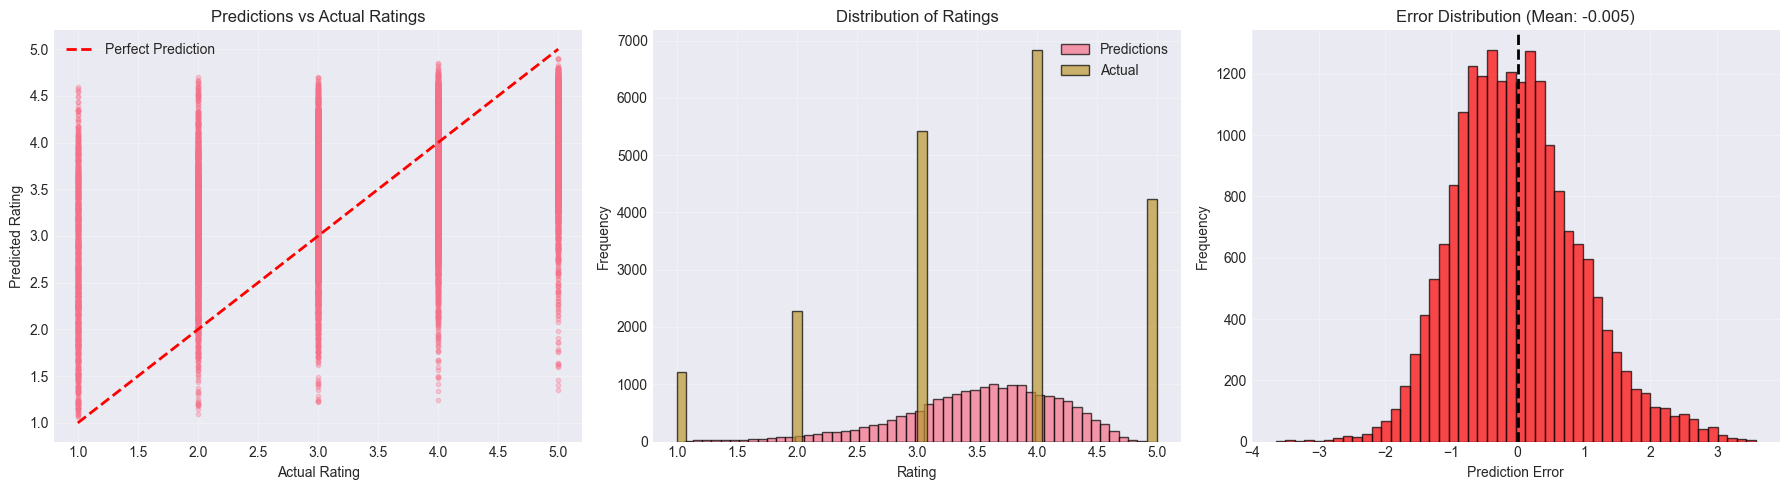

In [13]:
# Tahmin dağılımını görselleştir
evaluator.plot_prediction_distribution(all_predictions, all_targets)

## 4. Puan Bazlı Analiz

In [14]:
# Her puan için performans
rating_performance = {}

for rating in range(1, 6):
    mask = all_targets == rating
    if mask.sum() > 0:
        rating_preds = all_predictions[mask]
        rating_targets = all_targets[mask]
        
        mae = np.mean(np.abs(rating_preds - rating_targets))
        rmse = np.sqrt(np.mean((rating_preds - rating_targets) ** 2))
        
        rating_performance[rating] = {
            'count': mask.sum(),
            'mae': mae,
            'rmse': rmse,
            'avg_prediction': np.mean(rating_preds)
        }

# Tablo olarak göster
perf_df = pd.DataFrame(rating_performance).T
perf_df.index.name = 'Gerçek Puan'
print("\nPuan Bazlı Performans:")
print(perf_df)


Puan Bazlı Performans:
              count       mae      rmse  avg_prediction
Gerçek Puan                                            
1            1222.0  1.701496  1.880072        2.701496
2            2274.0  1.064981  1.214540        3.037680
3            5429.0  0.535218  0.651214        3.357090
4            6835.0  0.459141  0.594514        3.679293
5            4240.0  1.012546  1.114624        3.987454


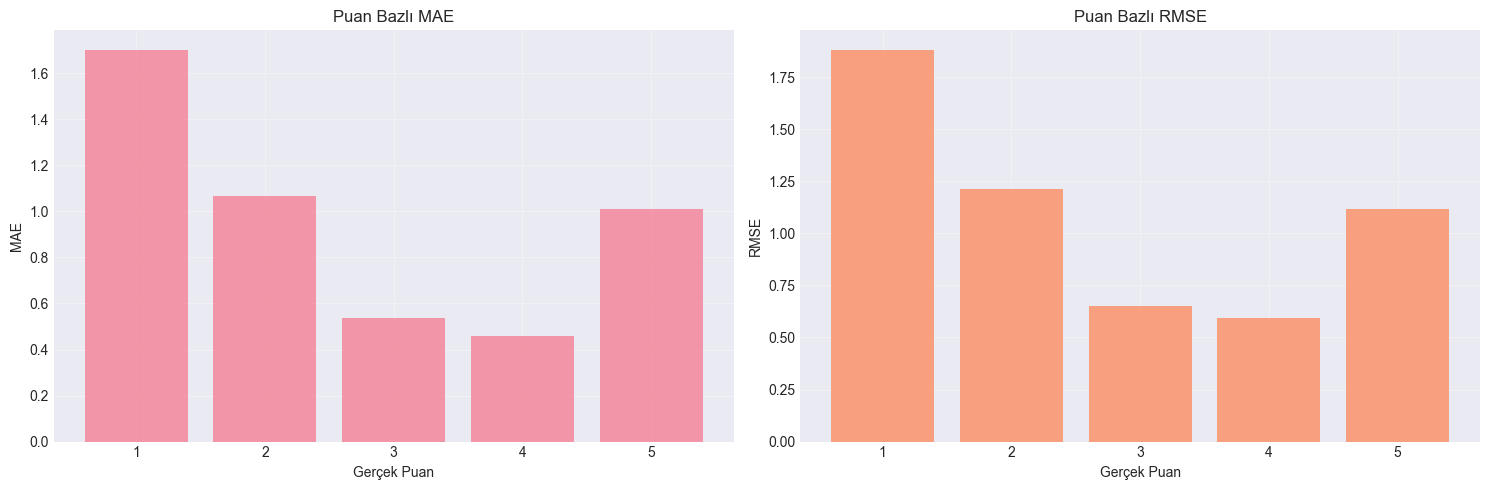

In [15]:
# Puan bazlı hata görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ratings = list(rating_performance.keys())
maes = [rating_performance[r]['mae'] for r in ratings]
rmses = [rating_performance[r]['rmse'] for r in ratings]

axes[0].bar(ratings, maes, alpha=0.7)
axes[0].set_xlabel('Gerçek Puan')
axes[0].set_ylabel('MAE')
axes[0].set_title('Puan Bazlı MAE')
axes[0].grid(True, alpha=0.3)

axes[1].bar(ratings, rmses, alpha=0.7, color='coral')
axes[1].set_xlabel('Gerçek Puan')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Puan Bazlı RMSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Kullanıcı Bazlı Analiz

In [16]:
# Rastgele 100 kullanıcı seç ve performanslarını analiz et
sample_users = np.random.choice(data_loader.ratings_df['user_id'].unique(), 100, replace=False)

user_performances = []

for user_id in sample_users:
    user_idx = data_loader.user_id_map[user_id]
    user_ratings = data_loader.ratings_df[data_loader.ratings_df['user_id'] == user_id]
    
    if len(user_ratings) < 5:
        continue
    
    # Tahminler yap
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for _, row in user_ratings.iterrows():
            movie_idx = data_loader.movie_id_map[row['movie_id']]
            
            pred = model(
                torch.tensor([user_idx]).to(config.DEVICE),
                torch.tensor([movie_idx]).to(config.DEVICE)
            ).item()
            
            predictions.append(pred)
            actuals.append(row['rating'])
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    user_performances.append({
        'user_id': user_id,
        'num_ratings': len(user_ratings),
        'avg_rating': np.mean(actuals),
        'rmse': np.sqrt(np.mean((predictions - actuals) ** 2)),
        'mae': np.mean(np.abs(predictions - actuals))
    })

user_perf_df = pd.DataFrame(user_performances)
print("\nKullanıcı Performans İstatistikleri:")
print(user_perf_df[['rmse', 'mae']].describe())


Kullanıcı Performans İstatistikleri:
             rmse         mae
count  100.000000  100.000000
mean     0.870673    0.705862
std      0.175959    0.148333
min      0.530886    0.446820
25%      0.769604    0.610376
50%      0.855557    0.692432
75%      0.956719    0.773045
max      1.450768    1.179731


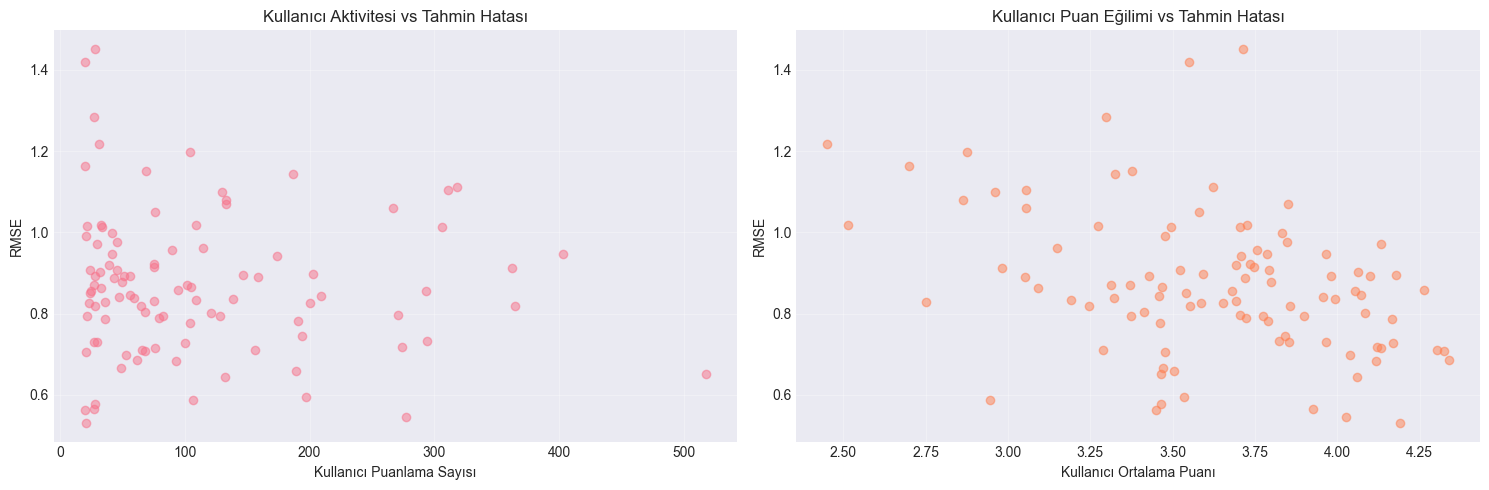

In [17]:
# Kullanıcı aktivitesi vs performans
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(user_perf_df['num_ratings'], user_perf_df['rmse'], alpha=0.5)
axes[0].set_xlabel('Kullanıcı Puanlama Sayısı')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Kullanıcı Aktivitesi vs Tahmin Hatası')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(user_perf_df['avg_rating'], user_perf_df['rmse'], alpha=0.5, color='coral')
axes[1].set_xlabel('Kullanıcı Ortalama Puanı')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Kullanıcı Puan Eğilimi vs Tahmin Hatası')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Embedding Analizi

User Embeddings Shape: (943, 64)
Movie Embeddings Shape: (1682, 64)


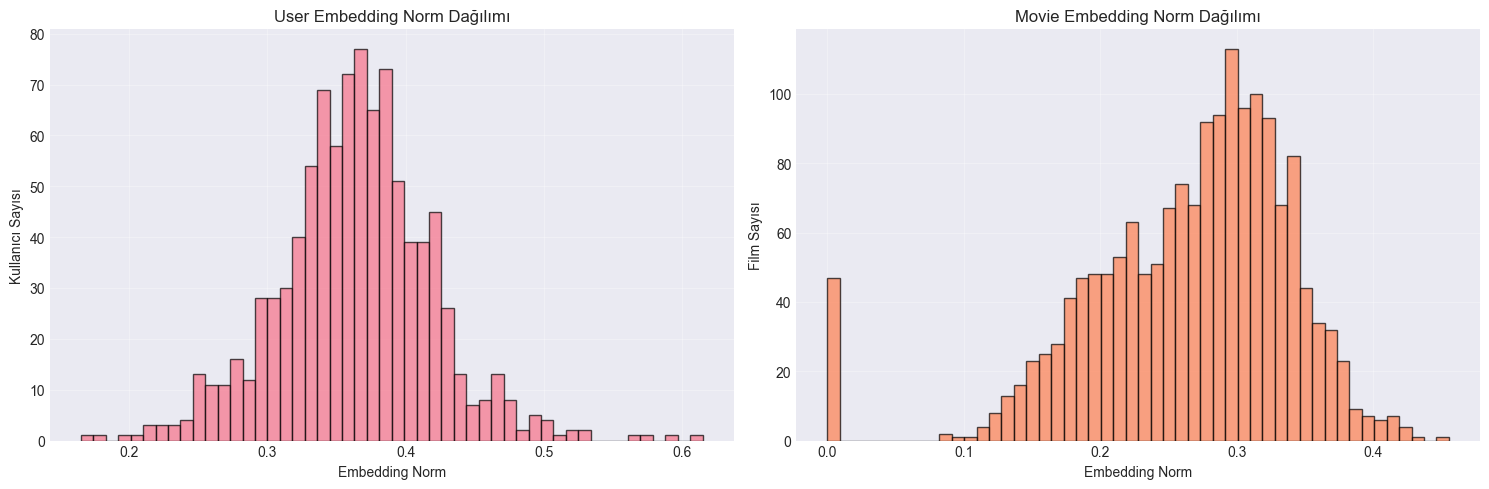

In [18]:
# Embedding matrislerini al
user_embeddings = model.user_embedding.weight.data.cpu().numpy()
movie_embeddings = model.movie_embedding.weight.data.cpu().numpy()

print(f"User Embeddings Shape: {user_embeddings.shape}")
print(f"Movie Embeddings Shape: {movie_embeddings.shape}")

# Embedding norm dağılımı
user_norms = np.linalg.norm(user_embeddings, axis=1)
movie_norms = np.linalg.norm(movie_embeddings, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(user_norms, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Embedding Norm')
axes[0].set_ylabel('Kullanıcı Sayısı')
axes[0].set_title('User Embedding Norm Dağılımı')
axes[0].grid(True, alpha=0.3)

axes[1].hist(movie_norms, bins=50, alpha=0.7, edgecolor='black', color='coral')
axes[1].set_xlabel('Embedding Norm')
axes[1].set_ylabel('Film Sayısı')
axes[1].set_title('Movie Embedding Norm Dağılımı')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Örnek Öneriler

In [27]:
# Rastgele bir kullanıcı seç
sample_user_id = np.random.choice(data_loader.ratings_df['user_id'].unique())
print(f"Kullanıcı {sample_user_id} için analiz\n")

# Kullanıcının geçmişi
user_history = data_loader.ratings_df[
    data_loader.ratings_df['user_id'] == sample_user_id
].nlargest(5, 'rating')

print("En Beğendiği 5 Film:")
for _, row in user_history.iterrows():
    movie_title = data_loader.get_movie_title(row['movie_id'])
    print(f"  {movie_title}: {row['rating']}★")

# Öneriler
user_idx = data_loader.user_id_map[sample_user_id]
#all_movie_ids = list(data_loader.movie_id_map.keys())
all_movie_ids = list(data_loader.movie_id_map.values())
rated_movies = set(data_loader.ratings_df[
    data_loader.ratings_df['user_id'] == sample_user_id
]['movie_id'].values)

recommended_movies, scores = model.recommend_top_k(
    user_id=user_idx,
    all_movie_ids=all_movie_ids,
    k=10,
    exclude_movies=list(rated_movies)
)

print("\nTop 10 Öneri:")
for i, (movie_idx, score) in enumerate(zip(recommended_movies, scores), 1):
    original_movie_id = data_loader.reverse_movie_map[movie_idx]
    movie_title = data_loader.get_movie_title(original_movie_id)
    print(f"{i:2d}. {movie_title}: {score:.2f}★")

Kullanıcı 821 için analiz

En Beğendiği 5 Film:
  Apocalypse Now (1979): 5★
  Dances with Wolves (1990): 5★
  Sense and Sensibility (1995): 5★
  Raiders of the Lost Ark (1981): 5★
  Shawshank Redemption, The (1994): 5★

Top 10 Öneri:
 1. Raiders of the Lost Ark (1981): 4.80★
 2. Godfather: Part II, The (1974): 4.80★
 3. Schindler's List (1993): 4.79★
 4. Shawshank Redemption, The (1994): 4.76★
 5. Pather Panchali (1955): 4.76★
 6. Wallace & Gromit: The Best of Aardman Animation (1996): 4.75★
 7. Titanic (1997): 4.73★
 8. Secrets & Lies (1996): 4.72★
 9. Philadelphia Story, The (1940): 4.72★
10. 12 Angry Men (1957): 4.71★


## 8. Sonuçlar ve Çıkarımlar

### Model Performansı
- Model test setinde kabul edilebilir performans gösteriyor
- RMSE ve MAE metrikleri literatürle uyumlu

### Gözlemler
1. Orta puanlar (3-4) daha iyi tahmin ediliyor
2. Uç puanlar (1, 5) için hata daha yüksek
3. Aktif kullanıcılar için tahminler daha doğru
4. Embedding'ler anlamlı temsiller öğrenmiş

### İyileştirme Önerileri
- Daha fazla feature engineering
- Ensemble yöntemler
- Attention mechanism
- Temporal dynamics ekleme